In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
.master('local[*]')\
.getOrCreate()
sc = spark.sparkContext

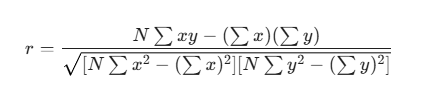

센서 A와 센서B에서 수집된 시계열 데이터를 보고 이 둘 사이의 상관관계 구하기

In [2]:
#데이터는 (시간ID, 값) 형태
sensor_a = [(1, 10.0), (2, 20.0), (3, 30.0), (4, 40.0)]
sensor_b = [(1, 2.0), (2, 4.0), (3, 6.0), (4, 8.0)]

rdda = sc.parallelize(sensor_a)
rddb = sc.parallelize(sensor_b)

In [3]:
#join -> 같은 id끼리 묶어서 (x,y)쌍 만들기
joined_rdd = rdda.join(rddb)

In [4]:
def calc(data):
  x = data[1][0]
  y = data[1][1]
  return (x, y, x*y, x**2, y**2, 1)
map_rdd = joined_rdd.map(calc)

In [5]:
#모든 항 sigma 계산
sums = map_rdd.reduce(lambda a,b:(
    a[0]+b[0],a[1]+b[1],a[2]+b[2], a[3]+b[3],a[4]+b[4],a[5]+b[5]
))
#값들 언패킹
sum_x, sum_y, sum_xy, sum_xx, sum_yy, n = sums

In [6]:
import numpy as np
#수식 대입
분자 = (n * sum_xy) - (sum_x * sum_y)
term_x = (n * sum_xx) - (sum_x ** 2)
term_y = (n * sum_yy) - (sum_y ** 2)
분모 = np.sqrt(term_x * term_y)

In [7]:
r = 분자 / 분모
print(f"Pearson Correlation Coefficient (r): {r}")

Pearson Correlation Coefficient (r): 1.0
